In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sse_core.compiler.parser import SSEParser
from sse_core.compiler.builder import SSECompiler
from sse_core.solvers.gillespie import GillespieSolver
from sse_core.solvers.export import TelemetryExporter

In [2]:
pbit_yaml_str = """
schema_version: "1.0.0"
simulation:
  solver: "gillespie"
  t_finish: 1.0e-5
  v_th: 0.026
  seed: 42
nodes:
  free:
    - {name: "node3"}
    - {name: "node4"}
  regulated:
    - name: "vdd"
      type: "constant"
      value: 0.0286
    - name: "vss"
      type: "constant"
      value: -0.0286
components:
  # NODE 3 CAPACITORS (Gate of Inv1 + Output of Inv2)
  - type: "capacitor"
    name: "C_gate_1_p"
    terminals: ["vdd", "node3"]
    specs: {capacitance: 50.0e-18}
  - type: "capacitor"
    name: "C_gate_1_n"
    terminals: ["vss", "node3"]
    specs: {capacitance: 50.0e-18}
  - type: "capacitor"
    name: "C_out_2_p"
    terminals: ["vdd", "node3"]
    specs: {capacitance: 0.5e-18}
  - type: "capacitor"
    name: "C_out_2_n"
    terminals: ["vss", "node3"]
    specs: {capacitance: 0.5e-18}

  # NODE 4 CAPACITORS (Output of Inv1 + Gate of Inv2)
  - type: "capacitor"
    name: "C_gate_2_p"
    terminals: ["vdd", "node4"]
    specs: {capacitance: 50.0e-18}
  - type: "capacitor"
    name: "C_gate_2_n"
    terminals: ["vss", "node4"]
    specs: {capacitance: 50.0e-18}
  - type: "capacitor"
    name: "C_out_1_p"
    terminals: ["vdd", "node4"]
    specs: {capacitance: 0.5e-18}
  - type: "capacitor"
    name: "C_out_1_n"
    terminals: ["vss", "node4"]
    specs: {capacitance: 0.5e-18}

  # STAGE 1 INVERTER (Input: node3 -> Output: node4)
  - type: "p_channel_mosfet"
    name: "M_inv1_p"
    terminals: {drain: "node4", gate: "node3", source: "vdd", bulk: "vdd"}
    specs: {I0: 1.6e-7, VT: 0.0, n: 1.0}
  - type: "n_channel_mosfet"
    name: "M_inv1_n"
    terminals: {drain: "node4", gate: "node3", source: "vss", bulk: "vss"}
    specs: {I0: 1.6e-7, VT: 0.0, n: 1.0}

  # STAGE 2 INVERTER (Input: node4 -> Output: node3)
  - type: "p_channel_mosfet"
    name: "M_inv2_p"
    terminals: {drain: "node3", gate: "node4", source: "vdd", bulk: "vdd"}
    specs: {I0: 1.6e-7, VT: 0.0, n: 1.0}
  - type: "n_channel_mosfet"
    name: "M_inv2_n"
    terminals: {drain: "node3", gate: "node4", source: "vss", bulk: "vss"}
    specs: {I0: 1.6e-7, VT: 0.0, n: 1.0}
"""


In [ ]:
# 1. Parse and Compile the YAML (assuming `pbit_yaml_str` contains your YAML)
assembly = SSECompiler.compile_string(pbit_yaml_str)
parsed_netlist = SSEParser.parse_string(pbit_yaml_str)

# Extract vr array dynamically
vr_dict = {node.name: node.value for node in parsed_netlist.nodes.regulated}
vr = np.array([vr_dict[name] for name in assembly.regulated_names], dtype=np.float64)

# 2. Simulate
solver = GillespieSolver(parsed_netlist, assembly)
q_init = np.zeros(len(assembly.free_names))

print("Simulating unbiased p-bit...")
# Note: t_finish is 1.0e-5 in YAML, which will generate a massive amount of data. 
# We'll limit max_steps to ensure it completes in a reasonable time for plotting.
history = solver.simulate(q_init, vr, max_steps=500000)

# Extract voltage traces (history['potentials'] contains the V(t) conversion)
# Let's map node3 to v1 and node4 to v2
v1_trace = history['potentials']['node3']
v2_trace = history['potentials']['node4']
t_trace = history['time']
v_th = 0.026
v_dd = 0.0286

# Export
filename = "fig14a.h5"
TelemetryExporter.export_to_hdf5(filename, history, assembly, v_th=v_th)


Simulating unbiased p-bit...


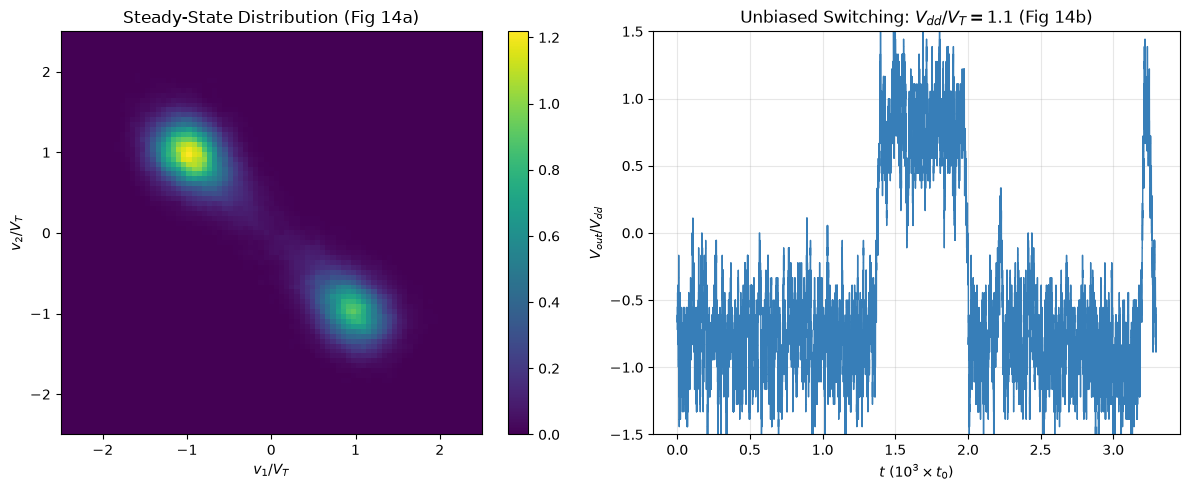

In [8]:
# 3. Visualization
fig = plt.figure(figsize=(12, 5))

# --- Plot 1: The 2D Steady-State Histogram (Fig 14a) ---
ax1 = fig.add_subplot(121)
# Discard the first 1% for burn-in
burn_in = int(len(v1_trace) * 0.01)
v1_steady = v1_trace[burn_in:] / v_th
v2_steady = v2_trace[burn_in:] / v_th

# --- ALIASING FIX: Extract the raw integer charge traces to align bins ---
idx_3 = assembly.free_names.index('node3')
idx_4 = assembly.free_names.index('node4')
q1_steady = history['charge'][burn_in:, idx_3]
q2_steady = history['charge'][burn_in:, idx_4]

# Calculate exactly how many discrete charge states exist in the data
num_bins_1 = int(np.max(q1_steady) - np.min(q1_steady)) + 1
num_bins_2 = int(np.max(q2_steady) - np.min(q2_steady)) + 1

# Create bin edges that perfectly frame the discrete voltage steps
dv1 = (np.max(v1_steady) - np.min(v1_steady)) / max(1, (num_bins_1 - 1))
dv2 = (np.max(v2_steady) - np.min(v2_steady)) / max(1, (num_bins_2 - 1))

bins_v1 = np.linspace(np.min(v1_steady) - dv1/2, np.max(v1_steady) + dv1/2, num_bins_1 + 1)
bins_v2 = np.linspace(np.min(v2_steady) - dv2/2, np.max(v2_steady) + dv2/2, num_bins_2 + 1)

# Create 2D histogram (heatmap) with aligned bins
h, xedges, yedges, image = ax1.hist2d(
    v1_steady, v2_steady, 
    bins=[bins_v1, bins_v2], 
    cmap='viridis', 
    density=True
)

# Fill the empty space with the colormap's zero-density background color
ax1.set_facecolor(image.cmap(0))

fig.colorbar(image, ax=ax1)
ax1.set_xlabel('$v_1 / V_T$')
ax1.set_ylabel('$v_2 / V_T$')
ax1.set_title('Steady-State Distribution (Fig 14a)')
ax1.set_xlim(-2.5, 2.5)
ax1.set_ylim(-2.5, 2.5)

# --- Plot 2: Time-Series Switching (Fig 14b) ---
ax2 = fig.add_subplot(122)
# Plot a subset of the time trace to clearly see the switches
plot_steps = min(100000, len(t_trace) - burn_in) 
t_plot = t_trace[burn_in : burn_in + plot_steps]
v1_plot = v1_trace[burn_in : burn_in + plot_steps] / v_dd

# Normalize time to t0 = 10^-12s (assuming I0=1.6e-7 A) for a cleaner x-axis
t0 = 1.0e-12 
t_plot_normalized = (t_plot - t_plot[0]) / (1e3 * t0)

ax2.step(t_plot_normalized, v1_plot, color='#377eb8', linewidth=1)
ax2.set_xlabel('$t \\ (10^3 \\times t_0)$')
ax2.set_ylabel('$V_{out} / V_{dd}$')
ax2.set_title(f'Unbiased Switching: $V_{{dd}}/V_T = {v_dd/v_th:.1f}$ (Fig 14b)')
ax2.set_ylim(-1.5, 1.5)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()